# Step 03: Separate Representation Training & Multi-Model Comparison

Trains each representation model in its own dedicated cell, evaluates performance on both the **Validation Set** and the **Held-Out Test Set (Unseen Subject)**, plots individual confusion matrices & metric breakdowns for both partitions, and presents a side-by-side comparative summary at the bottom.


In [1]:
# Cell 1: System Imports & Setup
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
root_dir = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
if str(root_dir) not in sys.path: sys.path.insert(0, str(root_dir))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.train_loso import run_loso_cross_validation
from src.benchmark_eval import run_benchmark_evaluation

sns.set_theme(style="whitegrid")
benchmark_results = {}
print("System ready for multi-representation training.")


System ready for multi-representation training.



>>> Training Representation 1 (REP1_DOPPLER) <<<

Starting 3-Fold Train/Val/Test LOSO Cross-Validation for Representation: rep1_doppler

--- Fold 0 | Train/Val Pool: Raffay, Towsif | Held-Out Test: Areeb ---
Extracting windows from 54 recording files...
Extracting windows from 14 recording files...
Extracting windows from 34 recording files...
Train windows: 166 | Val windows: 42 | Test windows: 112
  Epoch [05/15] Train Loss: 0.2262, Train Acc: 93.98%
  Epoch [10/15] Train Loss: 0.0991, Train Acc: 96.99%
  Epoch [15/15] Train Loss: 0.1766, Train Acc: 92.77%
Fold 0 Val Result -> Val Accuracy: 83.33%, Val Macro F1: 83.25%

--- Fold 1 | Train/Val Pool: Areeb, Towsif | Held-Out Test: Raffay ---
Extracting windows from 54 recording files...
Extracting windows from 14 recording files...
Extracting windows from 34 recording files...
Train windows: 172 | Val windows: 45 | Test windows: 103
  Epoch [05/15] Train Loss: 0.3380, Train Acc: 84.30%
  Epoch [10/15] Train Loss: 0.0890, Train Acc: 97

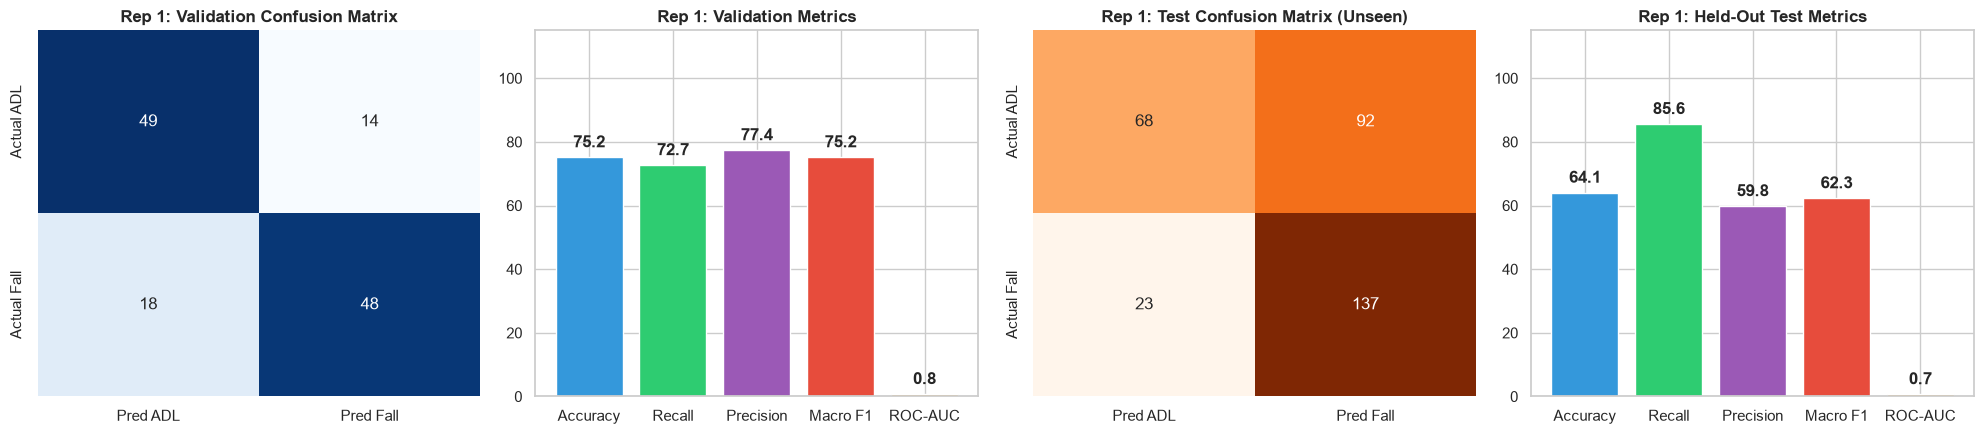

In [2]:
# Cell 2: Train & Evaluate Representation 1 (Micro-Doppler Time Map - ResNet-18)
rep1_key = "rep1_doppler"
print(f"\n>>> Training Representation 1 ({rep1_key.upper()}) <<<")
res1 = run_loso_cross_validation(rep_key=rep1_key, epochs=15, lr=5e-4, batch_size=32)
benchmark_results[rep1_key] = res1

# Plot Validation & Test Metrics for Representation 1
val_m1 = res1["val_metrics"]
test_m1 = res1["test_metrics"]
cm_val1 = np.array(val_m1["confusion_matrix"])
cm_test1 = np.array(test_m1["confusion_matrix"])

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), dpi=100)
sns.heatmap(cm_val1, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Pred ADL", "Pred Fall"], yticklabels=["Actual ADL", "Actual Fall"])
axes[0].set_title("Rep 1: Validation Confusion Matrix", fontweight="bold")

m_names = ["Accuracy", "Recall", "Precision", "Macro F1", "ROC-AUC"]
m_val_vals1 = [val_m1["accuracy"], val_m1["recall"], val_m1["precision"], val_m1["macro_f1"], val_m1["roc_auc"]]
bars1 = axes[1].bar(m_names, [v*100 if i < 4 else v for i, v in enumerate(m_val_vals1)], color=["#3498db", "#2ecc71", "#9b59b6", "#e74c3c", "#f39c12"])
axes[1].set_ylim(0, 115)
axes[1].set_title("Rep 1: Validation Metrics", fontweight="bold")
for bar in bars1:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 2, f"{h:.1f}", ha="center", va="bottom", fontweight="bold")

sns.heatmap(cm_test1, annot=True, fmt="d", cmap="Oranges", cbar=False, ax=axes[2],
            xticklabels=["Pred ADL", "Pred Fall"], yticklabels=["Actual ADL", "Actual Fall"])
axes[2].set_title("Rep 1: Test Confusion Matrix (Unseen)", fontweight="bold")

m_test_vals1 = [test_m1["accuracy"], test_m1["recall"], test_m1["precision"], test_m1["macro_f1"], test_m1["roc_auc"]]
bars1_t = axes[3].bar(m_names, [v*100 if i < 4 else v for i, v in enumerate(m_test_vals1)], color=["#3498db", "#2ecc71", "#9b59b6", "#e74c3c", "#f39c12"])
axes[3].set_ylim(0, 115)
axes[3].set_title("Rep 1: Held-Out Test Metrics", fontweight="bold")
for bar in bars1_t:
    h = bar.get_height()
    axes[3].text(bar.get_x() + bar.get_width()/2., h + 2, f"{h:.1f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()



>>> Training Representation 2 (REP2_PROJECTIONS) <<<

Starting 3-Fold Train/Val/Test LOSO Cross-Validation for Representation: rep2_projections

--- Fold 0 | Train/Val Pool: Raffay, Towsif | Held-Out Test: Areeb ---
Extracting windows from 54 recording files...
Extracting windows from 14 recording files...
Extracting windows from 34 recording files...
Train windows: 166 | Val windows: 42 | Test windows: 112
  Epoch [05/15] Train Loss: 0.0098, Train Acc: 100.00%
  Epoch [10/15] Train Loss: 0.0252, Train Acc: 100.00%
  Epoch [15/15] Train Loss: 0.0657, Train Acc: 96.99%
Fold 0 Val Result -> Val Accuracy: 92.86%, Val Macro F1: 92.85%

--- Fold 1 | Train/Val Pool: Areeb, Towsif | Held-Out Test: Raffay ---
Extracting windows from 54 recording files...
Extracting windows from 14 recording files...
Extracting windows from 34 recording files...
Train windows: 172 | Val windows: 45 | Test windows: 103
  Epoch [05/15] Train Loss: 0.0233, Train Acc: 100.00%
  Epoch [10/15] Train Loss: 0.0031, Tr

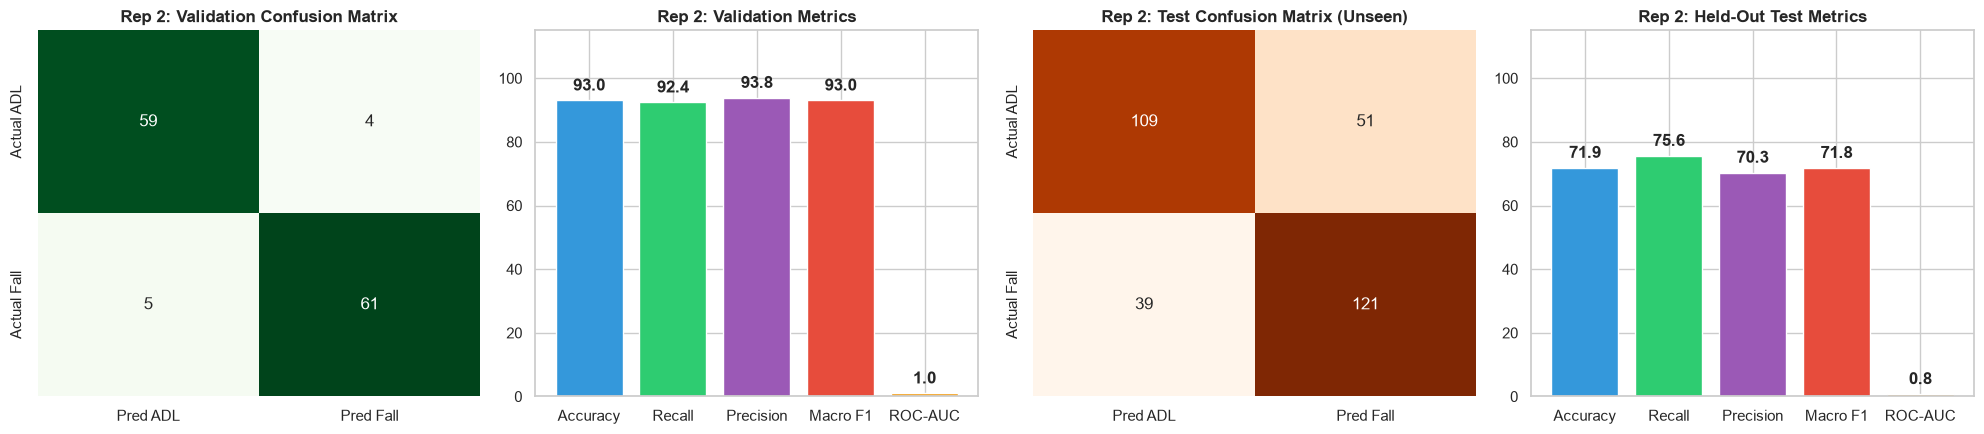

In [3]:
# Cell 3: Train & Evaluate Representation 2 (Spatial 2D Orthogonal Projections - ResNet-18)
rep2_key = "rep2_projections"
print(f"\n>>> Training Representation 2 ({rep2_key.upper()}) <<<")
res2 = run_loso_cross_validation(rep_key=rep2_key, epochs=15, lr=5e-4, batch_size=32)
benchmark_results[rep2_key] = res2

# Plot Validation & Test Metrics for Representation 2
val_m2 = res2["val_metrics"]
test_m2 = res2["test_metrics"]
cm_val2 = np.array(val_m2["confusion_matrix"])
cm_test2 = np.array(test_m2["confusion_matrix"])

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), dpi=100)
sns.heatmap(cm_val2, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[0],
            xticklabels=["Pred ADL", "Pred Fall"], yticklabels=["Actual ADL", "Actual Fall"])
axes[0].set_title("Rep 2: Validation Confusion Matrix", fontweight="bold")

m_val_vals2 = [val_m2["accuracy"], val_m2["recall"], val_m2["precision"], val_m2["macro_f1"], val_m2["roc_auc"]]
bars2 = axes[1].bar(m_names, [v*100 if i < 4 else v for i, v in enumerate(m_val_vals2)], color=["#3498db", "#2ecc71", "#9b59b6", "#e74c3c", "#f39c12"])
axes[1].set_ylim(0, 115)
axes[1].set_title("Rep 2: Validation Metrics", fontweight="bold")
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 2, f"{h:.1f}", ha="center", va="bottom", fontweight="bold")

sns.heatmap(cm_test2, annot=True, fmt="d", cmap="Oranges", cbar=False, ax=axes[2],
            xticklabels=["Pred ADL", "Pred Fall"], yticklabels=["Actual ADL", "Actual Fall"])
axes[2].set_title("Rep 2: Test Confusion Matrix (Unseen)", fontweight="bold")

m_test_vals2 = [test_m2["accuracy"], test_m2["recall"], test_m2["precision"], test_m2["macro_f1"], test_m2["roc_auc"]]
bars2_t = axes[3].bar(m_names, [v*100 if i < 4 else v for i, v in enumerate(m_test_vals2)], color=["#3498db", "#2ecc71", "#9b59b6", "#e74c3c", "#f39c12"])
axes[3].set_ylim(0, 115)
axes[3].set_title("Rep 2: Held-Out Test Metrics", fontweight="bold")
for bar in bars2_t:
    h = bar.get_height()
    axes[3].text(bar.get_x() + bar.get_width()/2., h + 2, f"{h:.1f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()



>>> Training Representation 3 (REP3_POINTSET) <<<

Starting 3-Fold Train/Val/Test LOSO Cross-Validation for Representation: rep3_pointset

--- Fold 0 | Train/Val Pool: Raffay, Towsif | Held-Out Test: Areeb ---
Extracting windows from 54 recording files...
Extracting windows from 14 recording files...
Extracting windows from 34 recording files...
Train windows: 166 | Val windows: 42 | Test windows: 112
  Epoch [05/15] Train Loss: 0.3074, Train Acc: 95.18%
  Epoch [10/15] Train Loss: 0.1183, Train Acc: 96.99%
  Epoch [15/15] Train Loss: 0.0412, Train Acc: 99.40%
Fold 0 Val Result -> Val Accuracy: 66.67%, Val Macro F1: 65.41%

--- Fold 1 | Train/Val Pool: Areeb, Towsif | Held-Out Test: Raffay ---
Extracting windows from 54 recording files...
Extracting windows from 14 recording files...
Extracting windows from 34 recording files...
Train windows: 172 | Val windows: 45 | Test windows: 103
  Epoch [05/15] Train Loss: 0.3895, Train Acc: 90.12%
  Epoch [10/15] Train Loss: 0.0435, Train Acc: 

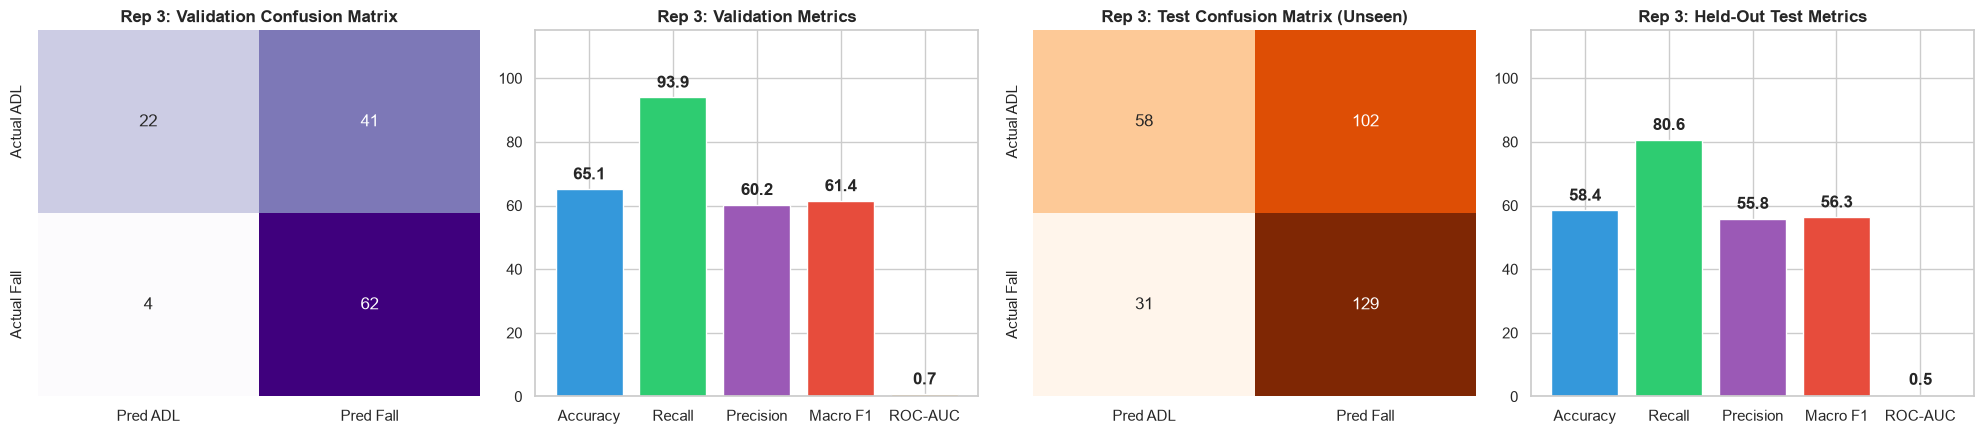

In [4]:
# Cell 4: Train & Evaluate Representation 3 (Native 3D Point Set - PointNet++)
rep3_key = "rep3_pointset"
print(f"\n>>> Training Representation 3 ({rep3_key.upper()}) <<<")
res3 = run_loso_cross_validation(rep_key=rep3_key, epochs=15, lr=5e-4, batch_size=32)
benchmark_results[rep3_key] = res3

# Plot Validation & Test Metrics for Representation 3
val_m3 = res3["val_metrics"]
test_m3 = res3["test_metrics"]
cm_val3 = np.array(val_m3["confusion_matrix"])
cm_test3 = np.array(test_m3["confusion_matrix"])

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), dpi=100)
sns.heatmap(cm_val3, annot=True, fmt="d", cmap="Purples", cbar=False, ax=axes[0],
            xticklabels=["Pred ADL", "Pred Fall"], yticklabels=["Actual ADL", "Actual Fall"])
axes[0].set_title("Rep 3: Validation Confusion Matrix", fontweight="bold")

m_val_vals3 = [val_m3["accuracy"], val_m3["recall"], val_m3["precision"], val_m3["macro_f1"], val_m3["roc_auc"]]
bars3 = axes[1].bar(m_names, [v*100 if i < 4 else v for i, v in enumerate(m_val_vals3)], color=["#3498db", "#2ecc71", "#9b59b6", "#e74c3c", "#f39c12"])
axes[1].set_ylim(0, 115)
axes[1].set_title("Rep 3: Validation Metrics", fontweight="bold")
for bar in bars3:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 2, f"{h:.1f}", ha="center", va="bottom", fontweight="bold")

sns.heatmap(cm_test3, annot=True, fmt="d", cmap="Oranges", cbar=False, ax=axes[2],
            xticklabels=["Pred ADL", "Pred Fall"], yticklabels=["Actual ADL", "Actual Fall"])
axes[2].set_title("Rep 3: Test Confusion Matrix (Unseen)", fontweight="bold")

m_test_vals3 = [test_m3["accuracy"], test_m3["recall"], test_m3["precision"], test_m3["macro_f1"], test_m3["roc_auc"]]
bars3_t = axes[3].bar(m_names, [v*100 if i < 4 else v for i, v in enumerate(m_test_vals3)], color=["#3498db", "#2ecc71", "#9b59b6", "#e74c3c", "#f39c12"])
axes[3].set_ylim(0, 115)
axes[3].set_title("Rep 3: Held-Out Test Metrics", fontweight="bold")
for bar in bars3_t:
    h = bar.get_height()
    axes[3].text(bar.get_x() + bar.get_width()/2., h + 2, f"{h:.1f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()



      TI mmWave Radar Fall Detection: Representation Benchmark Summary
| Representation                               |   Accuracy (%) |   Precision (%) |   Recall (%) |   Macro F1 (%) |   ROC-AUC |   False Alarm Rate / FPR (%) |   Latency (ms/seq) |
|:---------------------------------------------|---------------:|----------------:|-------------:|---------------:|----------:|-----------------------------:|-------------------:|
| Rep 1: Doppler-Time Map (ResNet-18)          |          75.19 |           77.42 |        72.73 |          75.19 |    0.7837 |                        22.22 |              14.22 |
| Rep 2: 2D Orthogonal Projections (ResNet-18) |          93.02 |           93.85 |        92.42 |          93.02 |    0.9861 |                         6.35 |              20.71 |
| Rep 3: Native 3D Point Tensor (PointNet++)   |          65.12 |           60.19 |        93.94 |          61.41 |    0.7007 |                        65.08 |               9.36 |
Saved benchmark summary tabl

C:\Users\joeyw\AppData\Local\Temp\ipykernel_20728\3507702790.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(df_plot["Rep Label"], rotation=15)
C:\Users\joeyw\AppData\Local\Temp\ipykernel_20728\3507702790.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[2].set_xticklabels(df_plot["Rep Label"], rotation=15)


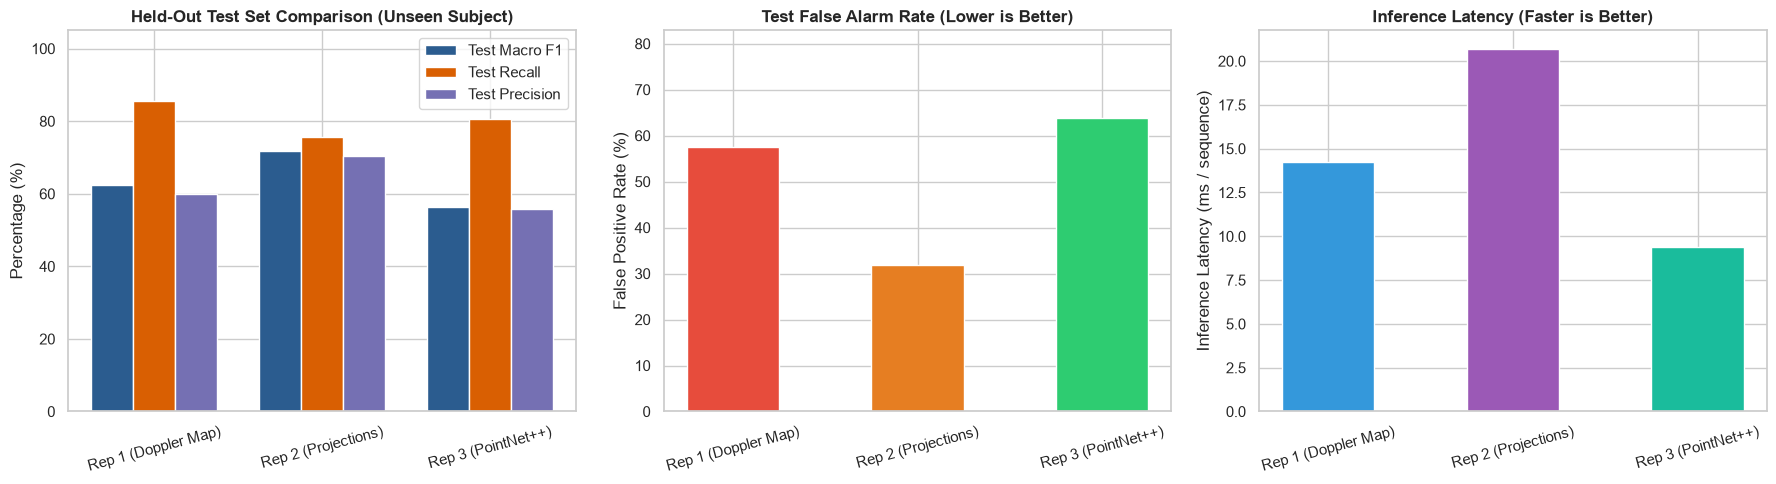

Saved final benchmark comparison plot to models\benchmarks\representation_benchmark_comparison.png


In [5]:
# Cell 5: Side-by-Side Representation Benchmark Comparison (Bottom Summary)
json_out_path = Path("models/benchmarks/loso_benchmark_results.json")
json_out_path.parent.mkdir(parents=True, exist_ok=True)
with open(json_out_path, "w", encoding="utf-8") as f:
    json.dump(benchmark_results, f, indent=4)

df_summary = run_benchmark_evaluation(json_out_path)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=100)
df_plot = df_summary.copy()
df_plot["Rep Label"] = ["Rep 1 (Doppler Map)", "Rep 2 (Projections)", "Rep 3 (PointNet++)"]
x_axis = np.arange(len(df_plot))
width = 0.25

# Extract Test metrics for bottom summary comparison
test_f1 = [res1["test_metrics"]["macro_f1"]*100, res2["test_metrics"]["macro_f1"]*100, res3["test_metrics"]["macro_f1"]*100]
test_rec = [res1["test_metrics"]["recall"]*100, res2["test_metrics"]["recall"]*100, res3["test_metrics"]["recall"]*100]
test_prec = [res1["test_metrics"]["precision"]*100, res2["test_metrics"]["precision"]*100, res3["test_metrics"]["precision"]*100]

axes[0].bar(x_axis - width, test_f1, width=width, label="Test Macro F1", color='#2b5c8f')
axes[0].bar(x_axis, test_rec, width=width, label="Test Recall", color='#d95f02')
axes[0].bar(x_axis + width, test_prec, width=width, label="Test Precision", color='#7570b3')
axes[0].set_xticks(x_axis)
axes[0].set_xticklabels(df_plot["Rep Label"], rotation=15)
axes[0].set_ylabel("Percentage (%)")
axes[0].set_title("Held-Out Test Set Comparison (Unseen Subject)", fontweight='bold')
axes[0].legend()
axes[0].set_ylim([0, 105])

test_fpr = [res1["test_metrics"]["fpr"]*100, res2["test_metrics"]["fpr"]*100, res3["test_metrics"]["fpr"]*100]
axes[1].bar(df_plot["Rep Label"], test_fpr, color=['#e74c3c', '#e67e22', '#2ecc71'], width=0.5)
axes[1].set_ylabel("False Positive Rate (%)")
axes[1].set_title("Test False Alarm Rate (Lower is Better)", fontweight='bold')
axes[1].set_xticklabels(df_plot["Rep Label"], rotation=15)
axes[1].set_ylim([0, max(max(test_fpr) * 1.3, 10.0)])

axes[2].bar(df_plot["Rep Label"], df_plot["Latency (ms/seq)"], color=['#3498db', '#9b59b6', '#1abc9c'], width=0.5)
axes[2].set_ylabel("Inference Latency (ms / sequence)")
axes[2].set_title("Inference Latency (Faster is Better)", fontweight='bold')
axes[2].set_xticklabels(df_plot["Rep Label"], rotation=15)

plt.tight_layout()
cmp_fig_path = Path("models/benchmarks/representation_benchmark_comparison.png")
plt.savefig(cmp_fig_path, dpi=300)
plt.show()
print(f"Saved final benchmark comparison plot to {cmp_fig_path}")
